<a href="https://colab.research.google.com/github/katjanieberle/sparks/blob/main/SPARKS_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Exploratory Data Analysis (EDA) on Marketing Data

Welcome, 5th-semester Data Science students at SPARKS university! This notebook serves as an example project for conducting Exploratory Data Analysis (EDA) on a marketing dataset. Our goal is to understand the dataset's structure, identify patterns, detect anomalies, and prepare it for further analysis or model building.

### Dataset: Marketing Data from Kaggle

We will be using the 'Marketing Data' dataset from Kaggle, available at: [https://www.kaggle.com/datasets/jackdaoud/marketing-data](https://www.kaggle.com/datasets/jackdaoud/marketing-data)

Let's start by setting up our environment and loading the data.

### Load Data into Pandas DataFrame

We will now load the `processed_marketing_data.csv` file into a pandas DataFrame, which is the primary data structure for data manipulation in Python.

In [3]:
import os
import pandas as pd

# Load the CSV file into a pandas DataFrame
df = pd.read_csv('https://raw.githubusercontent.com/katjanieberle/sparks/main/processed_marketing_data.csv')

print("First 5 rows of the dataset loaded from github:")
display(df.head())

First 5 rows of the dataset loaded from github:


,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Z_CostContact,Z_Revenue,Response,Age,Customer_Days,MntTotal,MntRegularProds,AcceptedCmpOverall,Education,Marital_Status
0,58138.0,0,0,58,635,88,546,172,88,88,...,3,11,1,63,2822,1529,1441,0,Graduation,Single
1,46344.0,1,1,38,11,1,6,2,1,6,...,3,11,0,66,2272,21,15,0,Graduation,Single
2,71613.0,0,0,26,426,49,127,111,21,42,...,3,11,0,55,2471,734,692,0,Graduation,Together
3,26646.0,1,0,26,11,4,20,10,3,5,...,3,11,0,36,2298,48,43,0,Graduation,Together
4,58293.0,1,0,94,173,43,118,46,27,15,...,3,11,0,39,2320,407,392,0,PhD,Married


### Initial Data Inspection

Before diving deep, it's crucial to get a general understanding of the dataset's structure, data types, and basic statistics. This helps in identifying potential issues like missing values, incorrect data types, or outliers.

In [ ]:
# Display concise summary of the DataFrame, including data types and non-null values
print("\nDataFrame Info:")
df.info()

# Generate descriptive statistics for numerical columns
# This includes count, mean, standard deviation, min, max, and quartiles.
print("\nDescriptive Statistics for Numerical Columns:")
display(df.describe())

# Generate descriptive statistics for all columns, including categorical ones
# The 'include='all'' argument ensures non-numerical columns are also summarized.
print("\nDescriptive Statistics for All Columns (including categorical):")
display(df.describe(include='all'))

In [ ]:
# Check for missing values in each column
# This returns the count of NaN values per column.
print("\nMissing values per column:")
display(df.isnull().sum())

### Further Exploratory Data Analysis (EDA)

Now that we have a basic understanding of the dataset's structure and missing values, let's perform a more in-depth analysis of its features. We'll categorize features into numerical and categorical types and explore their distributions and relationships.

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the list of columns that should be treated as categorical, even if they are numerical types (like 0/1 for AcceptedCmp* or Response)
explicitly_categorical = ['Response', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Complain']

# Separate numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()

# Move explicitly categorical columns from numerical to categorical lists if they exist in numerical_cols
for col in explicitly_categorical:
    if col in numerical_cols:
        numerical_cols.remove(col)
        if col not in categorical_cols: # Add only if not already there (e.g. if it was an object type already)
            categorical_cols.append(col)


print(f"Numerical columns: {numerical_cols}")
print(f"Categorical columns: {categorical_cols}")

Numerical columns: ['Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Z_CostContact', 'Z_Revenue', 'Age', 'Customer_Days', 'MntTotal', 'MntRegularProds', 'AcceptedCmpOverall']
Categorical columns: ['Education', 'Marital_Status', 'Response', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Complain']


### 1. Analysis of Categorical Features

Categorical features represent types of data that can be divided into groups. For these features, we are interested in:
- **Unique Values**: How many distinct categories exist.
- **Value Counts**: The frequency of each category.
- **Distribution**: Visualizing the distribution using bar plots.

This helps us understand the composition of our customer segments, product types, and other discrete attributes.


--- Analysis of Categorical Features ---

Column: Education
Unique values (5): ['Graduation' 'PhD' 'Master' 'Basic' '2n Cycle']
Value Counts:


,count
Education,
Graduation,1113
PhD,476
Master,364
2n Cycle,198
Basic,54


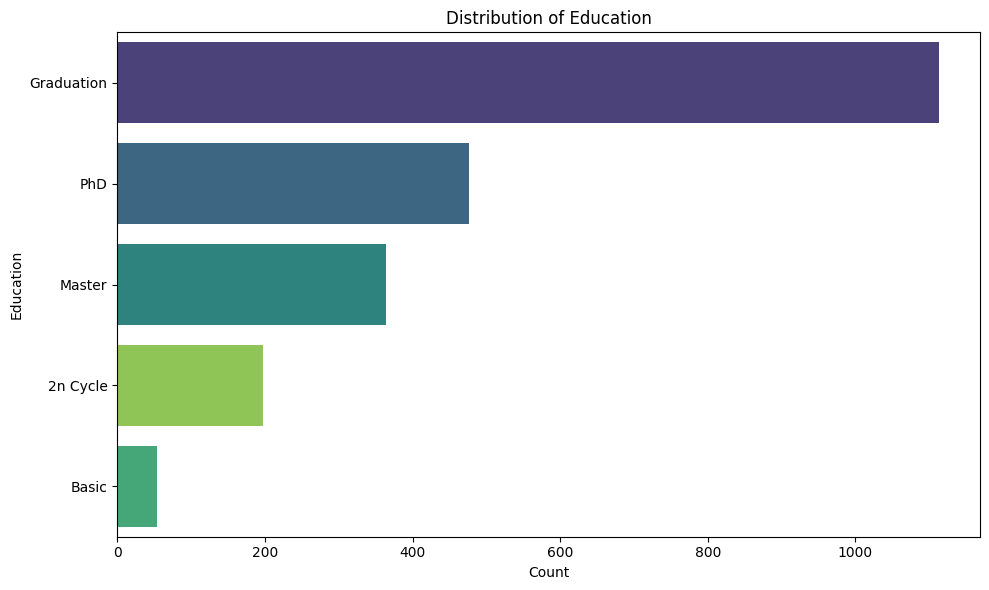

In [9]:
print("\n--- Analysis of Categorical Features ---")

#for col in categorical_cols:
for col in ['Education']:
    print(f"\nColumn: {col}")
    # Display unique values and their count
    print(f"Unique values ({df[col].nunique()}): {df[col].unique()}")
    # Display the frequency of each category
    print("Value Counts:")
    display(df[col].value_counts())

    # Visualize the distribution of categorical features
    plt.figure(figsize=(10, 6))
    sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='viridis', hue=col, legend=False)
    plt.title(f'Distribution of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

### 2. Analysis of Numerical Features

Numerical features are quantitative measurements. For these, we typically look at:
- **Distribution**: Using histograms to see the shape of the data (e.g., normal, skewed).
- **Central Tendency and Spread**: Mean, median, standard deviation from `describe()`.
- **Outliers**: Using box plots to identify extreme values that might indicate data entry errors or unusual events.

Understanding these aspects helps in identifying potential data quality issues, understanding the range and variability of our data, and making decisions about data transformation.


--- Analysis of Numerical Features ---

Column: Income


,Income
count,2205.000000
mean,51622.094785
std,20713.063826
min,1730.000000
25%,35196.000000
50%,51287.000000
75%,68281.000000
max,113734.000000


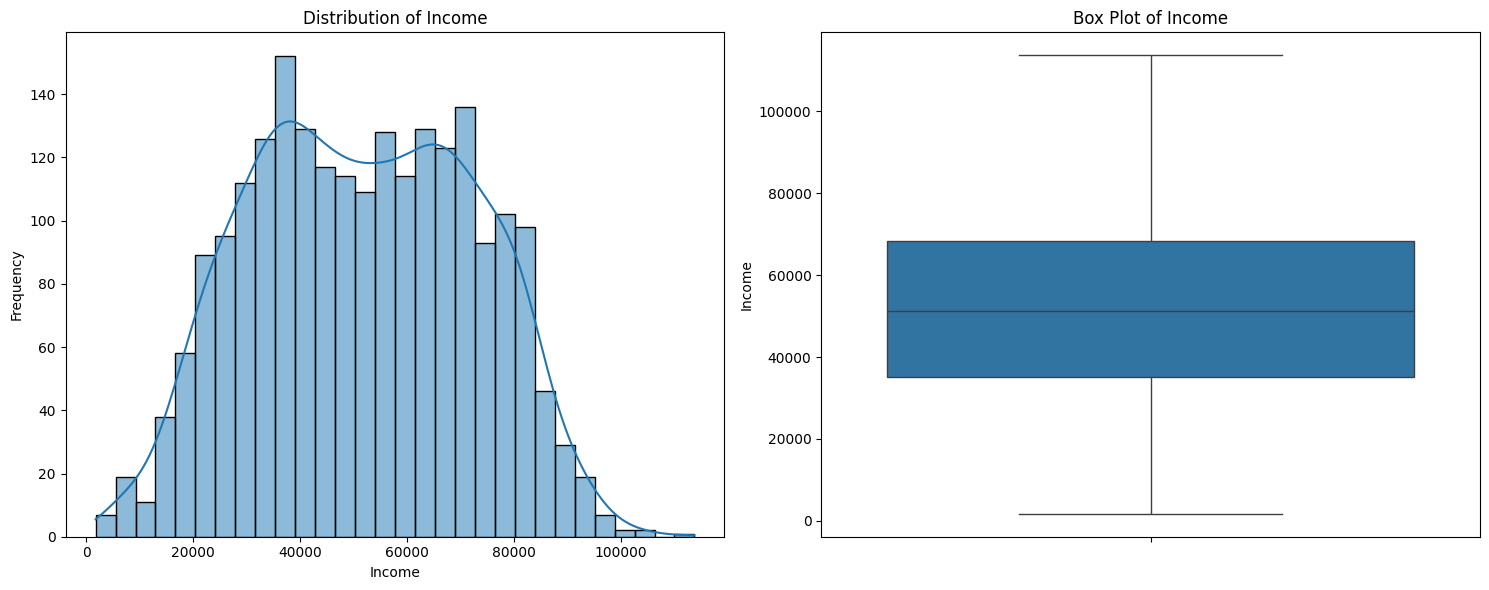

In [10]:
print("\n--- Analysis of Numerical Features ---")

#for col in numerical_cols:
#for col in ['Income', 'Kidhome', 'Teenhome', "Age"]:
for col in ['Income']:
    print(f"\nColumn: {col}")
    # Display descriptive statistics (already covered by df.describe() but useful for individual column view)
    display(df[col].describe())

    plt.figure(figsize=(15, 6))

    # Subplot 1: Histogram to show distribution
    plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
    sns.histplot(df[col].dropna(), kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    # Subplot 2: Box plot to show outliers and spread
    plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
    sns.boxplot(y=df[col].dropna())
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

### 3. Correlation Analysis

Correlation measures the statistical relationship between two variables. For numerical features, we can compute the Pearson correlation coefficient. A correlation matrix and heatmap help visualize these relationships:
- **Positive Correlation**: As one variable increases, the other tends to increase.
- **Negative Correlation**: As one variable increases, the other tends to decrease.
- **Zero Correlation**: No linear relationship.

This is useful for identifying highly related features (multicollinearity) or features that might be good predictors for each other.

In [ ]:
# Calculate the correlation matrix for numerical columns
correlation_matrix = df[numerical_cols].corr()
#correlation_matrix = df[['Income', 'Kidhome', 'Teenhome', "Age"]].corr()

print("\nCorrelation Matrix of Numerical Features:")
display(correlation_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

### 4. Relationships between Features

Exploring relationships between different types of features (e.g., numerical vs. categorical) can reveal important insights. For example, how does a numerical variable (like 'Income') vary across different categories (like 'Education')?

Box plots are excellent for this, showing the distribution of a numerical variable for each category.

In [ ]:
print("\n--- Relationships between Numerical and Categorical Features ---")

# Let's pick a few key categorical and numerical columns for deeper analysis

# Example 1: Income vs. Education Level
# This box plot helps visualize how income distributions differ across various education levels.
# Outliers and median shifts can indicate disparities or correlations.
if 'Income' in numerical_cols and 'Education' in categorical_cols:
    plt.figure(figsize=(12, 7))
    sns.boxplot(x='Education', y='Income', data=df, palette='pastel', hue='Education', legend=False)
    plt.title('Income Distribution by Education Level')
    plt.xlabel('Education Level')
    plt.ylabel('Income')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("'Income' or 'Education' column not found for this analysis.")

# Example 2: Number of Children (Numerical representation) vs. Marital Status
# By creating a 'TotalChildren' feature, we can explore how family size might correlate with marital status.
# This can reveal common family structures within different marital segments.
if 'Kidhome' in numerical_cols and 'Teenhome' in numerical_cols and 'Marital_Status' in categorical_cols:
    df['TotalChildren'] = df['Kidhome'] + df['Teenhome']
    plt.figure(figsize=(12, 7))
    sns.boxplot(x='Marital_Status', y='TotalChildren', data=df, palette='pastel', hue='Marital_Status', legend=False)
    plt.title('Total Children Distribution by Marital Status')
    plt.xlabel('Marital Status')
    plt.ylabel('Total Children')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Relevant columns for 'TotalChildren' or 'Marital_Status' not found for this analysis.")

# Example 3: Spend on various products vs. Customer Type (e.g., 'Response' to campaign)
# This analysis investigates if customers who responded to a campaign ('Response' = 1)
# exhibit different spending patterns across product categories compared to those who didn't.
# Converting 'Response' to object type for correct categorical plotting if it's still numerical.
mnt_cols = [col for col in numerical_cols if col.startswith('Mnt')]

# Ensure 'Response' is treated as categorical for this plot
if 'Response' in df.columns:
    df['Response'] = df['Response'].astype(str)
    if len(mnt_cols) > 0:
        df_mnt = df[mnt_cols + ['Response']].melt(id_vars='Response', var_name='Product', value_name='AmountSpent')
        plt.figure(figsize=(15, 8))
        sns.boxplot(x='Product', y='AmountSpent', hue='Response', data=df_mnt, palette='deep')
        plt.title('Amount Spent on Products by Campaign Response')
        plt.xlabel('Product Category')
        plt.ylabel('Amount Spent')
        plt.xticks(rotation=45)
        plt.legend(title='Response (1=Yes, 0=No)')
        plt.tight_layout()
        plt.show()
    else:
        print("Product spending columns not found for this analysis.")
else:
    print("'Response' column not found for this analysis.")

Updated Numerical columns: ['Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Z_CostContact', 'Z_Revenue', 'Age', 'Customer_Days', 'MntTotal', 'MntRegularProds', 'AcceptedCmpOverall', 'TotalChildren']
Updated Categorical columns: ['Response', 'Education', 'Marital_Status', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Complain']


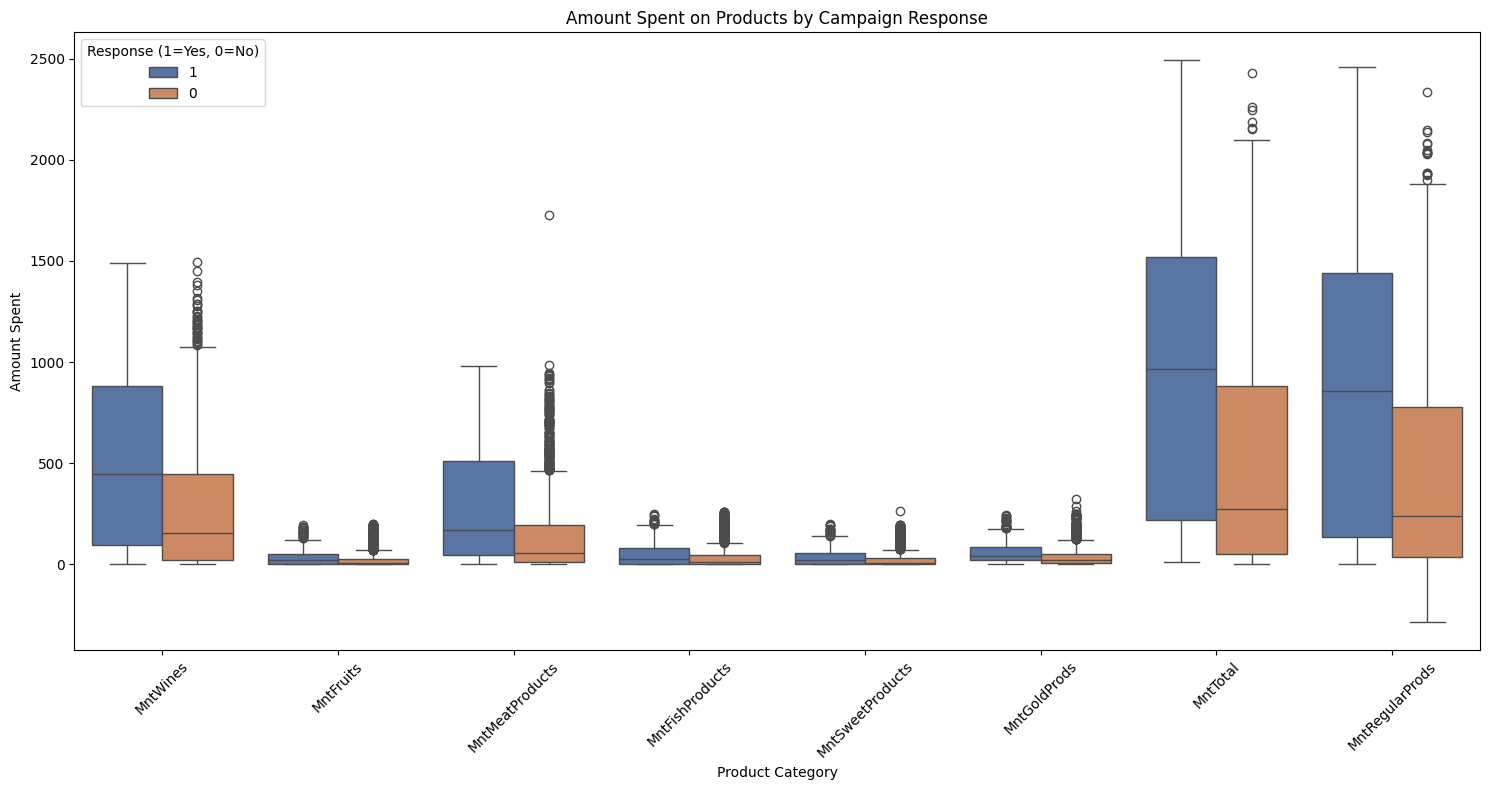

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Re-execute the logic from cell 52a245ec to ensure categorical/numerical lists are updated ---
# Define the list of columns that should be treated as categorical, even if they are numerical types (like 0/1 for AcceptedCmp* or Response)
explicitly_categorical = ['Response', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Complain']

# Separate numerical and categorical columns
# Re-initialize to ensure fresh state if 'df' has been modified elsewhere
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()

# Move explicitly categorical columns from numerical to categorical lists if they exist in numerical_cols
for col in explicitly_categorical:
    if col in numerical_cols:
        numerical_cols.remove(col)
        if col not in categorical_cols:
            categorical_cols.append(col)

print(f"Updated Numerical columns: {numerical_cols}")
print(f"Updated Categorical columns: {categorical_cols}")

# --- Re-execute the relevant plotting logic from cell 4f496dd1 for the 'Response' column ---
# Example 3: Spend on various products vs. Customer Type (e.g., 'Response' to campaign)
# This analysis investigates if customers who responded to a campaign ('Response' = 1)
# exhibit different spending patterns across product categories compared to those who didn't.
# Converting 'Response' to object type for correct categorical plotting if it's still numerical.
mnt_cols = [col for col in numerical_cols if col.startswith('Mnt')]

# Ensure 'Response' is treated as categorical for this plot
if 'Response' in df.columns:
    df['Response'] = df['Response'].astype(str)
    if len(mnt_cols) > 0:
        df_mnt = df[mnt_cols + ['Response']].melt(id_vars='Response', var_name='Product', value_name='AmountSpent')
        plt.figure(figsize=(15, 8))
        sns.boxplot(x='Product', y='AmountSpent', hue='Response', data=df_mnt, palette='deep')
        plt.title('Amount Spent on Products by Campaign Response')
        plt.xlabel('Product Category')
        plt.ylabel('Amount Spent')
        plt.xticks(rotation=45)
        plt.legend(title='Response (1=Yes, 0=No)')
        plt.tight_layout()
        plt.show()
    else:
        print("Product spending columns not found for this analysis.")
else:
    print("'Response' column not found for this analysis.")

## Summary of Exploratory Data Analysis (EDA)

This notebook provided a comprehensive example of Exploratory Data Analysis on the marketing dataset, tailored for 5th-semester Media & Data Science students.

We covered:
1.  **Initial Data Inspection**: Understanding the dataset's structure, data types, and identifying missing values using `df.info()` and `df.describe()`.
2.  **Categorical Feature Analysis**: Exploring unique values, their counts, and distributions using bar plots (`sns.countplot`). This helped us understand the composition of customer segments by education and marital status.
3.  **Numerical Feature Analysis**: Examining the distributions, central tendencies, spread, and potential outliers of numerical features through histograms and box plots (`sns.histplot`, `sns.boxplot`).
4.  **Correlation Analysis**: Visualizing linear relationships between numerical features using a correlation matrix and heatmap (`sns.heatmap`). This helps identify highly correlated variables.
5.  **Relationships between Numerical and Categorical Features**: Investigating how numerical variables vary across different categories using box plots. Specifically, we looked at:
    *   Income distribution by Education Level.
    *   Total children distribution by Marital Status.
    *   Spending patterns on various products by campaign response, giving insights into the effectiveness of marketing campaigns.

### Next Steps for Your Project

For your further studies and projects at SPARKS University, consider these next steps:

*   **Feature Engineering**: Based on the insights from EDA, create new features (e.g., `Age_Group`, `IsParent`, `TotalSpent`) that might be more predictive for a machine learning model.
*   **Outlier Treatment**: Decide how to handle the identified outliers in numerical features. Options include removal, capping (winsorization), or transformation.
*   **Missing Value Imputation**: Although this dataset had no missing values, for other datasets, you would need to choose appropriate imputation strategies (mean, median, mode, regression imputation).
*   **Data Scaling/Normalization**: Prepare numerical features for machine learning models that are sensitive to the scale of input features (e.g., K-Means, SVMs, Neural Networks).
*   **Hypothesis Testing**: Formulate specific hypotheses based on your EDA findings and test them statistically to confirm relationships (e.g., "Is there a significant difference in income between different education levels?").
*   **Segmentation**: Use clustering algorithms (e.g., K-Means) to identify natural customer segments based on their demographics and spending habits.
*   **Predictive Modeling**: Formulate a business problem (e.g., predicting campaign response, customer lifetime value) and build machine learning models using the processed data.

Remember to document all your steps, decisions, and findings clearly. Good luck with your data science journey!